In [1]:
import os
import pickle
import numpy as np
import shutil

current_dir = os.getcwd()
gcad_dir = os.path.join(current_dir, 'GCAD')
al_memory_dir = os.path.join(current_dir, 'active_learning_loop', 'al_memory')

# 1. Load the AI's final belief cloud
cloud_path = os.path.join(al_memory_dir, 'final_posterior_belief.pkl')
with open(cloud_path, 'rb') as f:
    belief_cloud = pickle.load(f)

# 2. Extract the Mean (The Calibrated Truth)
final_mean_parameters = {}
for key in belief_cloud[0].keys():
    stacked = np.array([model[key] for model in belief_cloud])
    final_mean_parameters[key] = np.mean(stacked, axis=0)

# 3. Create a Safety Backup of Nominal Parameters
parts_path = os.path.join(gcad_dir, 'parts.pkl')
backup_path = os.path.join(gcad_dir, 'parts_nominal_backup.pkl')

if not os.path.exists(backup_path):
    shutil.copy(parts_path, backup_path)
    print("✅ Created safety backup of nominal 'parts.pkl'")

# 4. Overwrite the New Calibrated Parameters
with open(parts_path, 'rb') as f:
    parts_dict = pickle.load(f)

print("\n--- OVERWRITING CALIBRATED PARAMETERS ---")
for part in final_mean_parameters.keys():
    print(f"Updating {part}:")
    print(f"  Old: {parts_dict[part]}")
    parts_dict[part] = final_mean_parameters[part]
    print(f"  New: {parts_dict[part]}")

with open(parts_path, 'wb') as f:
    pickle.dump(parts_dict, f)
    
print("\n GCAD updated with AL-calibrated parameters.")


--- OVERWRITING CALIBRATED PARAMETERS ---
Updating Z1:
  Old: [ 0.08  33.     0.036]
  New: [ 0.08  33.     0.036]
Updating Z2:
  Old: [2.5e-01 5.4e+01 1.8e-02]
  New: [2.5e-01 5.4e+01 1.8e-02]
Updating Z6:
  Old: [ 0.01718745 10.93734809  0.043     ]
  New: [1.80067541e-02 7.02733896e+01 4.30000000e-02]
Updating Z7:
  Old: [1.1e-01 4.6e+01 2.5e-02]
  New: [1.1e-01 4.6e+01 2.5e-02]
Updating Z8:
  Old: [7.0e-02 4.3e+01 4.1e-02]
  New: [7.0e-02 4.3e+01 4.1e-02]
Updating Z9:
  Old: [ 0.46  33.     0.096]
  New: [ 0.46  33.     0.096]
Updating Z10:
  Old: [1.0e-02 3.1e+01 3.7e-02]
  New: [1.0e-02 3.1e+01 3.7e-02]
Updating Z11:
  Old: [8.0e-02 3.2e+01 2.5e-02]
  New: [8.0e-02 3.2e+01 2.5e-02]
Updating Z12:
  Old: [ 0.15  33.     0.065]
  New: [ 0.15  33.     0.065]
Updating Z13:
  Old: [4.0e-02 4.1e+01 1.2e-02]
  New: [4.0e-02 4.1e+01 1.2e-02]
Updating Z14:
  Old: [ 0.2   30.     0.069]
  New: [ 0.2   30.     0.069]
Updating Z15:
  Old: [1.8e-01 3.3e+01 7.0e-03]
  New: [1.8e-01 3.3e+01 7.0

In [2]:
import sys
import os
import json
import datetime
import numpy as np

current_dir = os.getcwd()
gcad_dir = os.path.join(current_dir, 'GCAD')

os.chdir(gcad_dir)

if gcad_dir not in sys.path:
    sys.path.append(gcad_dir)

import GA as ga_ops
from GA_setup import multi_obj_GA
from pulse_generator_problem import PulseGenerator

os.chdir(current_dir)
print("✅ GCAD Modules Imported.")

# 1. Load GCAD Settings 
settings_path = os.path.join(current_dir, 'GCAD', "FreeSearch_settings.json")
with open(settings_path, "r") as f:
    settings = json.load(f)

# 2. Setup Post-AL Output Folder
timestamp = datetime.datetime.now().strftime("%Y-%m-%d")
phys_tag = "PostAL_Calibrated_DsRed" 
OUTPUT_FOLDER = os.path.join(current_dir, "results", f"Miner_{phys_tag}_{timestamp}")

if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

print(f"\n--- POST-AL FREE SEARCH CONFIGURATION ---")
print(f"Generations:   {settings['n_gen']}")
print(f"Population:    {sum(settings['num_dict'].values())} circuits")
print(f"Output:        {OUTPUT_FOLDER}\n")

# 3. Initialize Problem with Calibrated Engine
problem = PulseGenerator(
    promo_node=settings["promo_node"],
    dose_specs=settings["dose_specs"],
    max_part=settings["max_part"],
    inhibitor=settings["inhibitor"],
    DsRed_inhibitor=settings["DsRed_inhibitor"],
    num_dict=settings["num_dict"],
    n_gen=settings["n_gen"],
    probability_crossover=settings["probability_crossover"],
    probability_mutation=settings["probability_mutation"],
    mutate_dose=settings["mutate_dose"],
    pop=settings["pop"],
    obj_labels=settings["obj_labels"],
    max_time=settings["max_time"]
)

# 4. Run Evolution
print(">> Sampling Initial Population...")
population = ga_ops.sampling(problem.promo_node, problem.num_dict, problem.min_dose, 
                             problem.max_dose, problem.dose_interval, problem.inhibitor)

obj = np.asarray([problem.func(ind[0]) for ind in population])

num_circuits = int(sum(settings["num_dict"].values()))
print(f">> STARTING EVOLUTION ({settings['n_gen']} Generations)...")

multi_obj_GA(
    folder_path=OUTPUT_FOLDER,
    problem=problem,
    population=population,
    num_circuits=num_circuits,
    obj=obj,
    get_unique=False,
    plot=False
)
print(">> EVOLUTION DONE.")

Loaded 12 Activators and 12 Inhibitors.
✅ GCAD Modules Imported.

--- POST-AL FREE SEARCH CONFIGURATION ---
Generations:   100
Population:    200 circuits
Output:        c:\Users\KuangQi\Desktop\GCAD-SDL\GCAD-SDL\Self_Calibrating_Loop\results\Miner_PostAL_Calibrated_DsRed_2026-03-01

>> Sampling Initial Population...
>> STARTING EVOLUTION (100 Generations)...
Starting Evolution (100 Generations)...


Evolving: 100%|██████████| 100/100 [27:31<00:00, 16.52s/gen, Max Prominence=41.31]



Saving results to pickle files...
Done! Results saved in c:\Users\KuangQi\Desktop\GCAD-SDL\GCAD-SDL\Self_Calibrating_Loop\results\Miner_PostAL_Calibrated_DsRed_2026-03-01
>> EVOLUTION DONE.


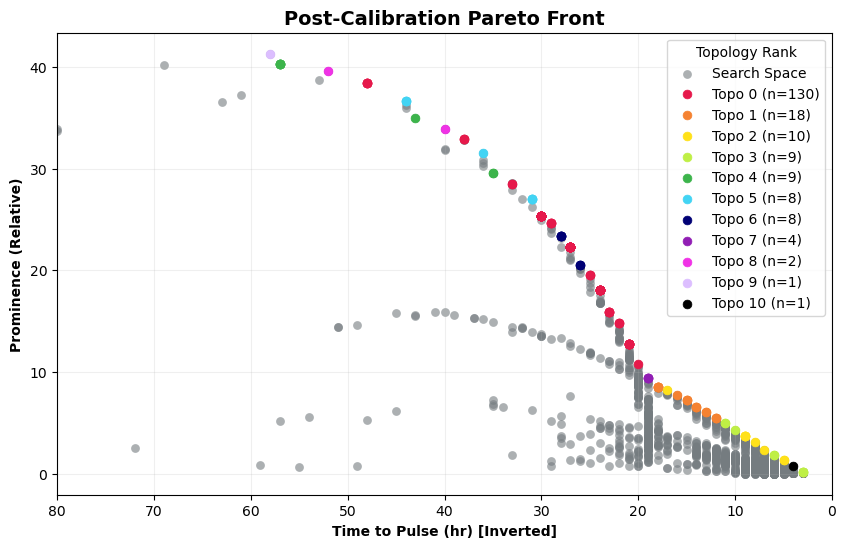


COLOR-MATCHED CIRCUIT SCHEMATICS


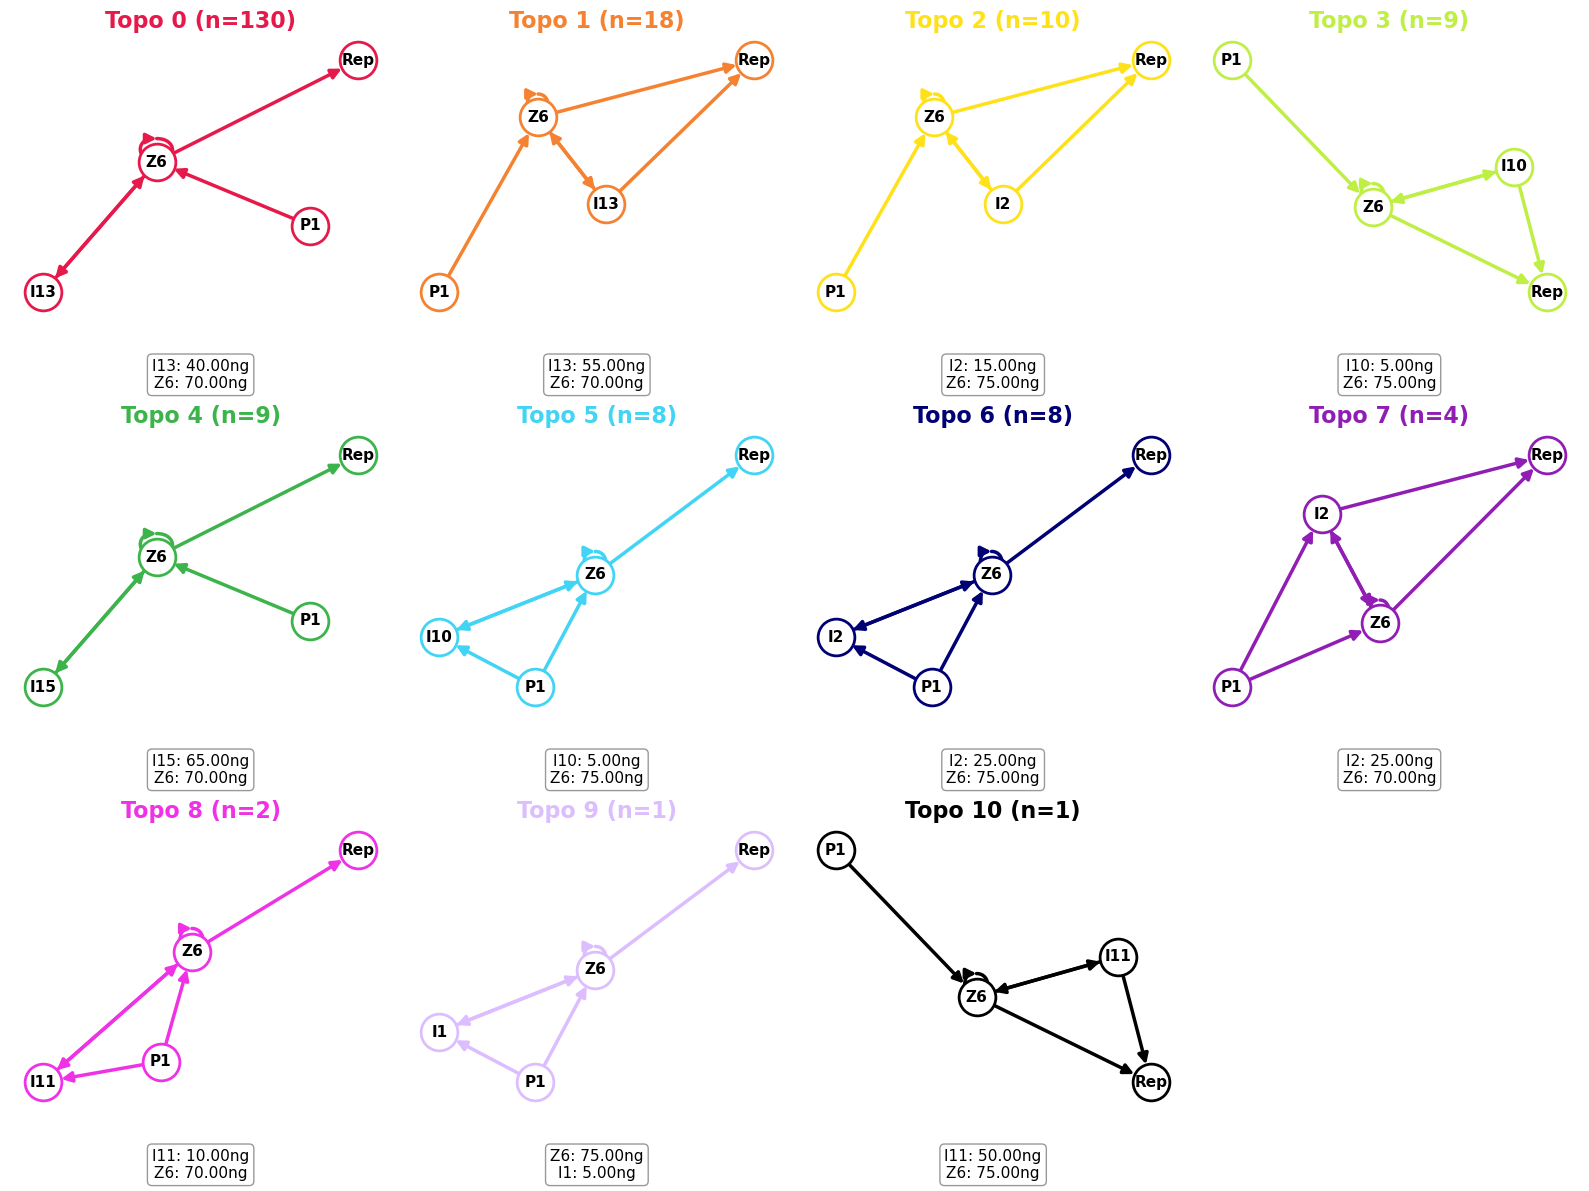


--- NEW DOMINANT ARCHITECTURES ---
Arch 1: 139 circuits | Sig: (('A', 'A'), ('A', 'R'), ('A', 'Rep'), ('P1', 'A'), ('R', 'A'))
Arch 2: 38 circuits | Sig: (('A', 'A'), ('A', 'R'), ('A', 'Rep'), ('P1', 'A'), ('R', 'A'), ('R', 'Rep'))
Arch 3: 19 circuits | Sig: (('A', 'A'), ('A', 'R'), ('A', 'Rep'), ('P1', 'A'), ('P1', 'R'), ('R', 'A'))
Arch 4: 4 circuits | Sig: (('A', 'A'), ('A', 'R'), ('A', 'Rep'), ('P1', 'A'), ('P1', 'R'), ('R', 'A'), ('R', 'Rep'))


In [8]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx 

TOPO_COLORS = ['#e6194B', '#f58231', '#ffe119', '#bfef45', '#3cb44b', '#42d4f4', '#000075', "#911eb4", "#f032e6", '#dcbeff', "#000000"]

def abstract_edges(edge_list):
    generic = []
    for u, v in edge_list:
        src = 'P1' if u == 'P1' else ('A' if u.startswith('Z') else ('R' if u.startswith('I') else u))
        tgt = 'Rep' if v == 'Rep' else ('A' if v.startswith('Z') else ('R' if v.startswith('I') else v))
        generic.append((src, tgt))
    return tuple(sorted(generic))

# Load Post-AL Data dynamically
df = pd.read_pickle(os.path.join(OUTPUT_FOLDER, "final_objectives_df.pkl"))
with open(os.path.join(OUTPUT_FOLDER, "final_population.pkl"), "rb") as f:
    pop = pickle.load(f)
history_df = pd.read_pickle(os.path.join(OUTPUT_FOLDER, "unique_objectives_df.pkl"))

df['circuit_object'] = [ind[0] for ind in pop]
if 'prominence_rel' in df.columns and df['prominence_rel'].mean() < 0:
    df['prominence_rel'] = -df['prominence_rel'] 
    history_df['prominence_rel'] = -history_df['prominence_rel']

df['topology_sig'] = df['circuit_object'].apply(lambda c: str(tuple(sorted(c.edge_list))))
df['abstract_sig'] = df['circuit_object'].apply(lambda c: abstract_edges(c.edge_list))

valid_df = df[df['prominence_rel'] > 0.1].copy()

# PARETO FRONT PLOT
topo_counts = valid_df['topology_sig'].value_counts()
sorted_sigs = topo_counts.index.tolist()
sig_to_id = {sig: i for i, sig in enumerate(sorted_sigs)}
sig_to_color = {sig: TOPO_COLORS[i % len(TOPO_COLORS)] for i, sig in enumerate(sorted_sigs)}

plt.figure(figsize=(10, 6))
plt.scatter(history_df['t_pulse'], history_df['prominence_rel'], 
            c="#757c80", s=40, alpha=0.6, linewidths=0, label='Search Space')

for sig in sorted_sigs:
    subset = valid_df[valid_df['topology_sig'] == sig]
    plt.scatter(subset['t_pulse'], subset['prominence_rel'], 
                c=sig_to_color[sig], s=40, alpha=1.0, linewidth=0.5, zorder=10,
                label=f"Topo {sig_to_id[sig]} (n={topo_counts[sig]})")

plt.xlim(0, 80)
plt.gca().invert_xaxis()
plt.xlabel("Time to Pulse (hr) [Inverted]", fontweight='bold')
plt.ylabel("Prominence (Relative)", fontweight='bold')
plt.title("Post-Calibration Pareto Front", fontweight='bold', fontsize=14)
if len(sorted_sigs) < 15: plt.legend(title="Topology Rank", loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

# --- PLOT 2: SPECIFIC SCHEMATICS (Color-Matched) ---
print("\n" + "="*40)
print("COLOR-MATCHED CIRCUIT SCHEMATICS")
print("="*40)

num = len(sorted_sigs)
cols = min(num, 4) 
rows = int(np.ceil(num / cols))

if rows > 0:
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    if num == 1: axes = np.array([axes])
    axes = axes.flatten()
    
    for i, sig in enumerate(sorted_sigs):
        ax = axes[i]
        rep_row = valid_df[valid_df['topology_sig'] == sig].sort_values('prominence_rel', ascending=False).iloc[0]
        rep_circuit = rep_row['circuit_object']
        
        color = sig_to_color[sig] # Directly matching the Pareto front color
        count = topo_counts[sig]
        
        G = nx.DiGraph(rep_circuit.edge_list)
        pos = nx.spring_layout(G, seed=25)
        
        nx.draw(G, pos, ax=ax, node_color='white', edgecolors=color, linewidths=2, node_size=700, 
                with_labels=True, font_weight='bold', font_size=11, edge_color=color, width=2.5, arrowsize=15)
        
        ax.set_title(f"Topo {i} (n={count})", color=color, fontweight='bold', fontsize=16)
        dose_str = "\n".join([f"{k}: {v:.2f}ng" for k, v in rep_circuit.dose.items() if k!='Rep'])
        ax.text(0.5, -0.15, dose_str, transform=ax.transAxes, ha='center', va='top', fontsize=11, 
                bbox=dict(boxstyle="round,pad=0.3", edgecolor='gray', facecolor='white', alpha=0.8))
        
    for j in range(i+1, len(axes)): 
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# ARCHITECTURE STATS
abs_counts = valid_df['abstract_sig'].value_counts().reset_index()
abs_counts.columns = ['abstract_sig', 'Count']
print("\n--- NEW DOMINANT ARCHITECTURES ---")
for i, row in abs_counts.head(5).iterrows():
    print(f"Arch {i+1}: {row['Count']} circuits | Sig: {row['abstract_sig']}")